In [1]:
from spyplotter import Spectrum, LineIdentifier, SpectralLine
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SpectralQuantity, SpectralCoord
%matplotlib widget

# Initialization of a Spectrum

You can either create a spectrum from two arrays directly:

In [2]:
spectrum = Spectrum([1,2,3],[5,6,7])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read it from a *.plot file from a PoWR model:

In [3]:
spectrum_contplines = Spectrum.from_powr(
    filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/wruniq.plot',
    keywords=['EMERGENT'],
    dataset=3
)

spyplotter.spectrum - INFO - Flux calibrated spectrum at 10 pc. Thus using erg / (Angstrom s cm2) as y unit.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed


Dataset 3 corresponds to the spectrum that contains continuum + lines.




You can also read an observed spectrum from a table file (e.g. csv) with numpy or pandas and then create a Spectrum object:

In [4]:
filename = '../tests/test_data/simulated_spectrum.csv'
data_sim = np.loadtxt(filename, skiprows=1,delimiter=',')
spectrum_sim = Spectrum(data_sim[:,0],data_sim[:,1])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read from a file containing a xy table:

In [5]:
spectrum_sim = Spectrum.from_file(filename,skiprows=1,delimiter=',')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


# Plot spectrum

When plotting the spectrum, you can choose the flux units and the units for the x-axis by using the common astropy units:

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


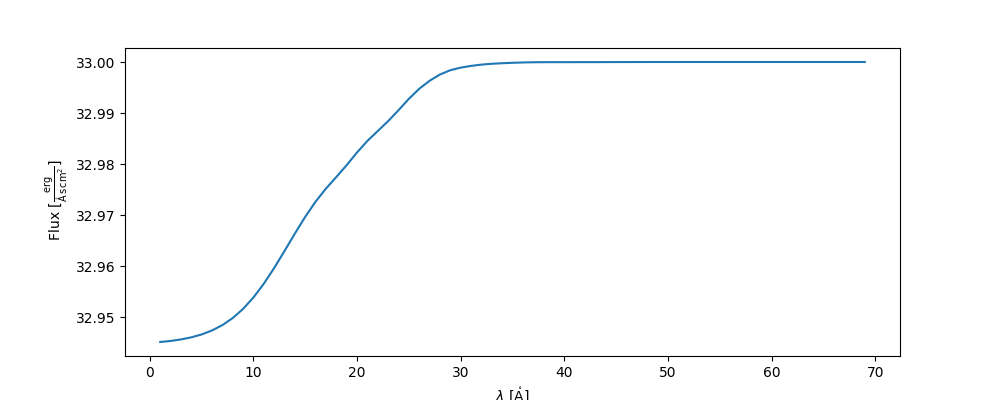

In [6]:
fig = spectrum_contplines.plot(x_unit=u.AA);

You can easily plot another normalized spectrum:

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


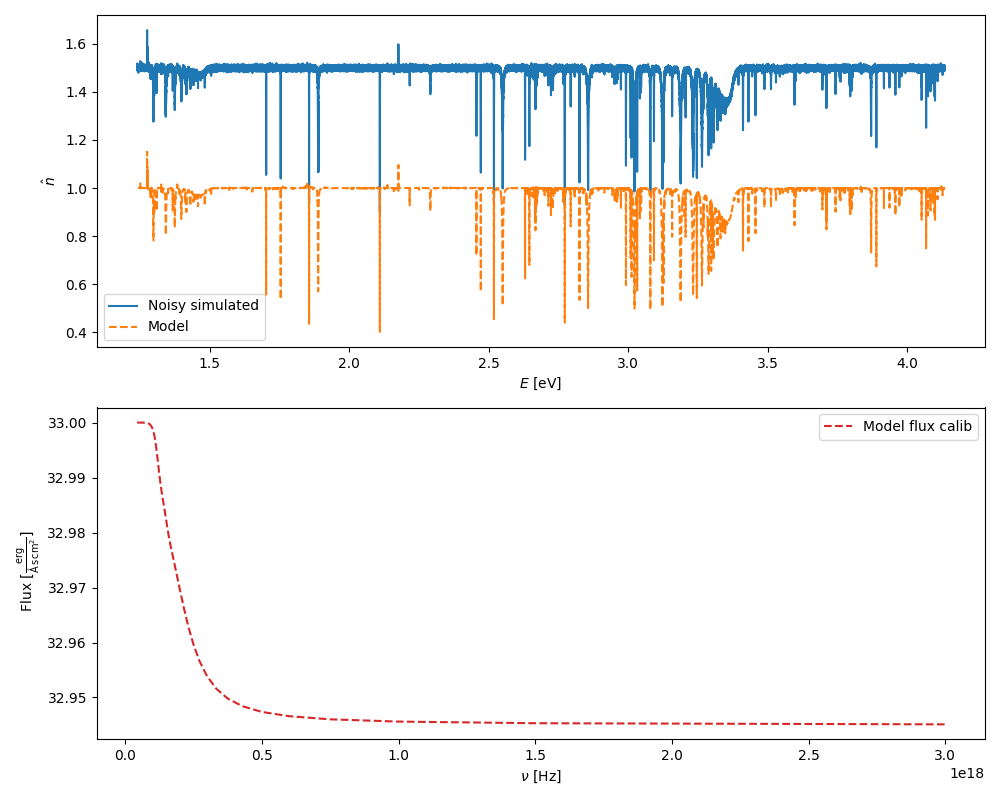

In [7]:
spectrum_norm = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)

fig,ax = plt.subplots(2,1,figsize=(10,8))

spectrum_sim.plot(x_unit=u.eV,ax=ax[0],color='C00',label='Noisy simulated',yshift=0.5);
spectrum_norm.plot(x_unit=u.eV,ax=ax[0],ls='--',color='C01',label='Model');
spectrum_contplines.plot(x_unit=u.Hz,ax=ax[1],ls='--',color='C03',label='Model flux calib');

for i in range(2):
    ax[i].legend()
plt.tight_layout()

In [8]:
print(spectrum_sim.y.unit)

If you want to zoom into specific regions:

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


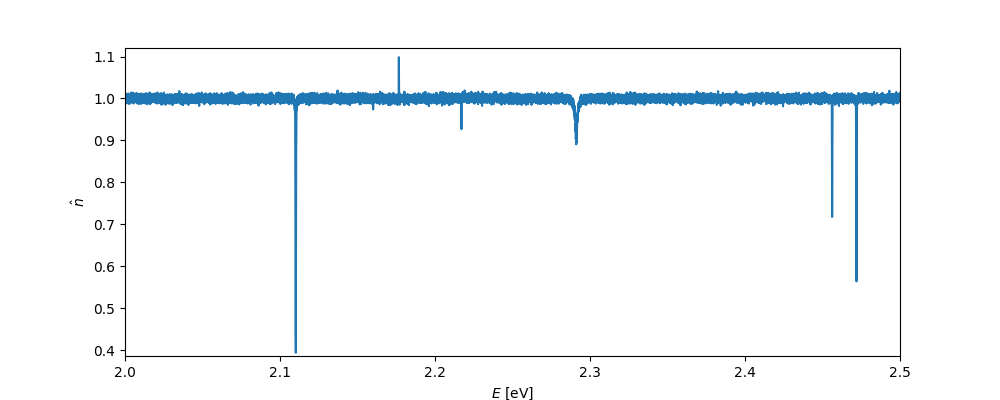

In [9]:
spectrum_sim.plot(x_unit=u.eV,color='C00',label='Noisy simulated',interval=[2,2.5]);

If you want to zoom into multiple regions, use plot_zoom and a list of intervals. 

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


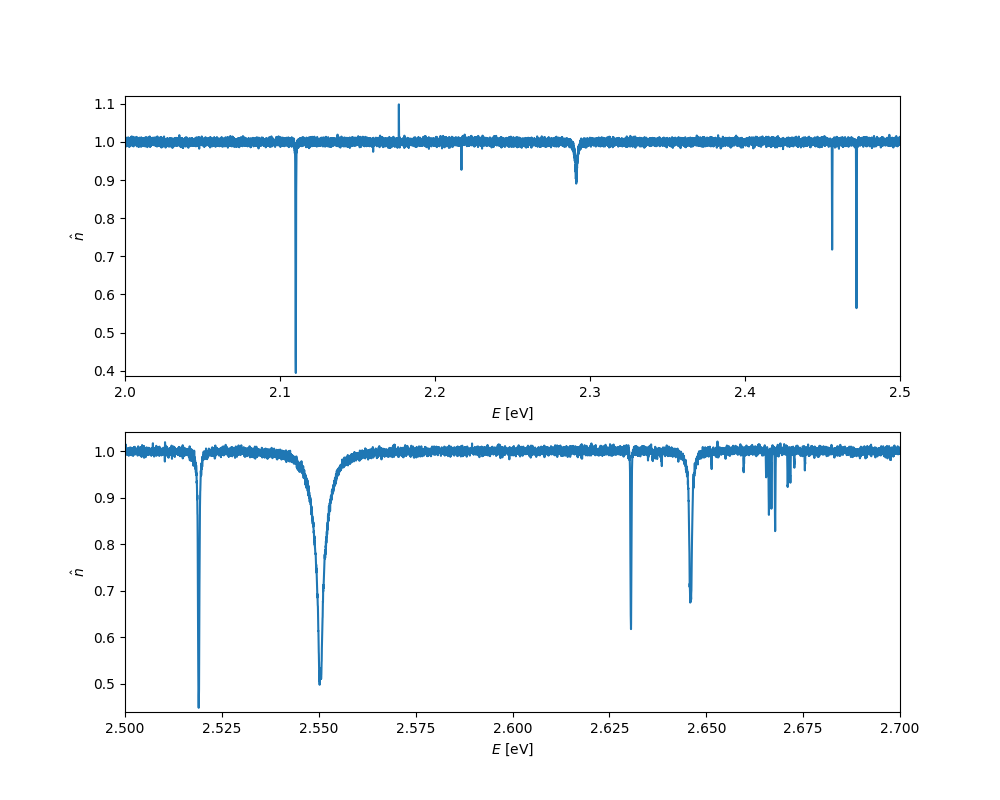

In [10]:
spectrum_sim.plot_zoom(x_unit=u.eV,color='C00',label='Noisy simulated',intervals=[[2,2.5],[2.5,2.7]]);

If intervals is an integer, it will split the full spectrum equally into the number of specified intervals:

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


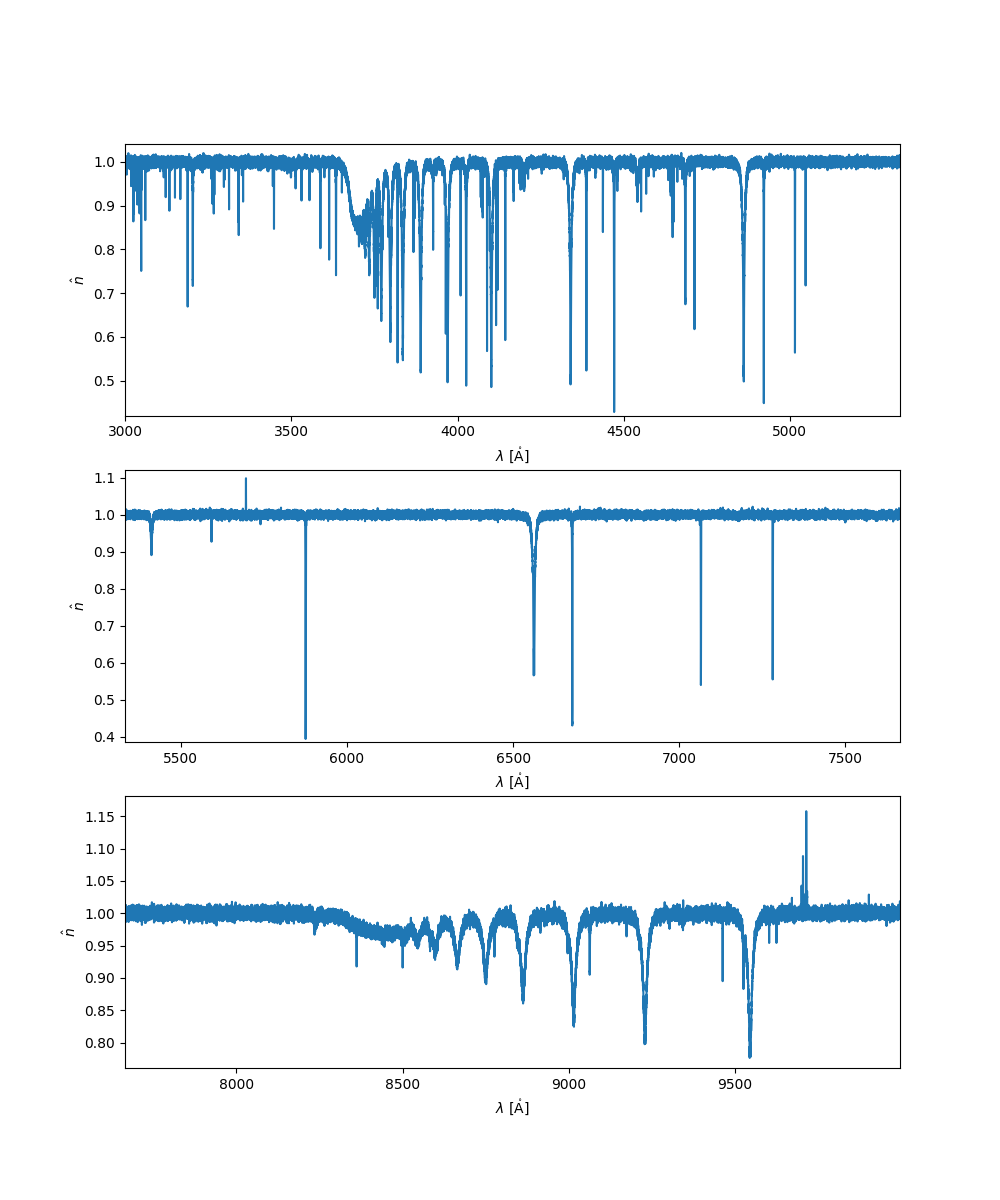

In [11]:
spectrum_sim.plot_zoom(intervals=3);

You can also use the helper function generate_intervals to get equally spaced intervals.

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


[[2.0, 2.25], [2.25, 2.5], [2.5, 2.75], [2.75, 3.0]]


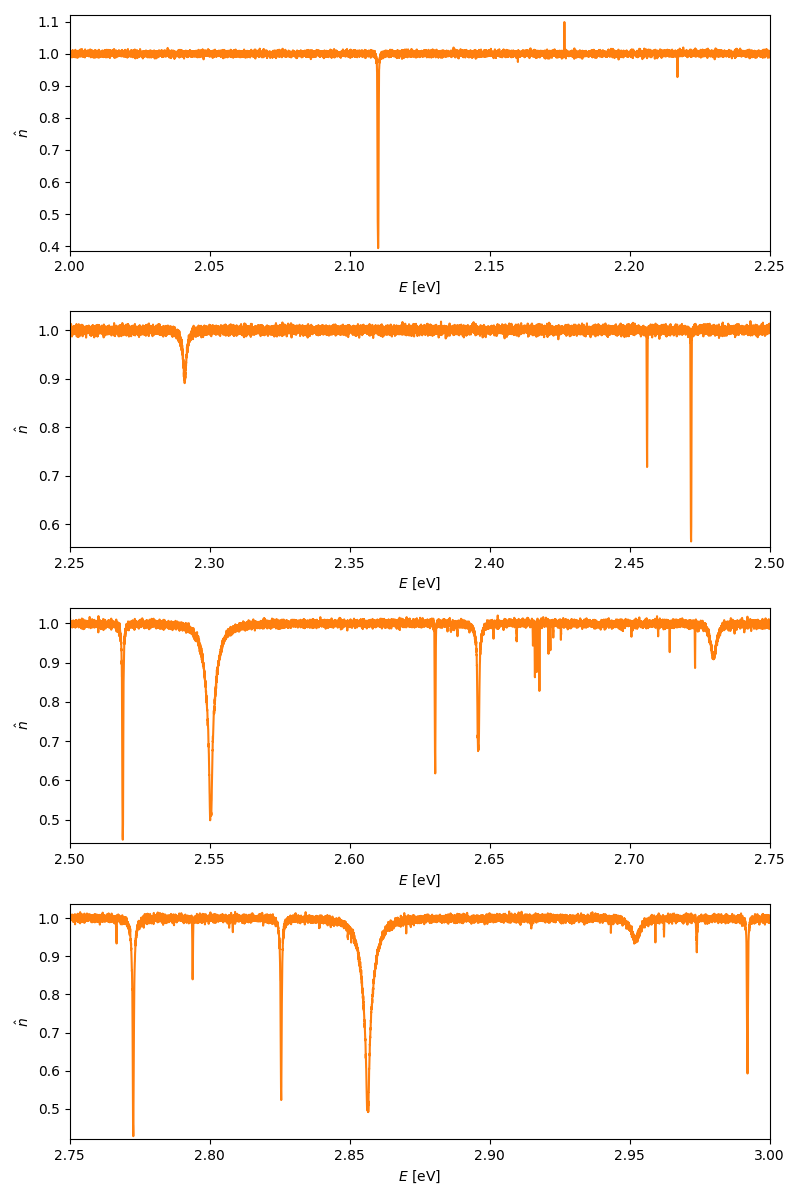

In [12]:
from spyplotter.spec_tools import generate_intervals
intervals = generate_intervals(interval_start=2,interval_end=3,n_int=4)
print(intervals)

spectrum_sim.plot_zoom(x_unit=u.eV,intervals=intervals,fig_height=3,fig_width=8,color='C01');
plt.tight_layout()

# Convert whole spectrum into other units

In [13]:
spectrum_sim.x_unit

Unit("Angstrom")

In [14]:
spectrum_sim.convert_units(x_unit=u.nm)

In [15]:
spectrum_sim.x_unit

Unit("nm")

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


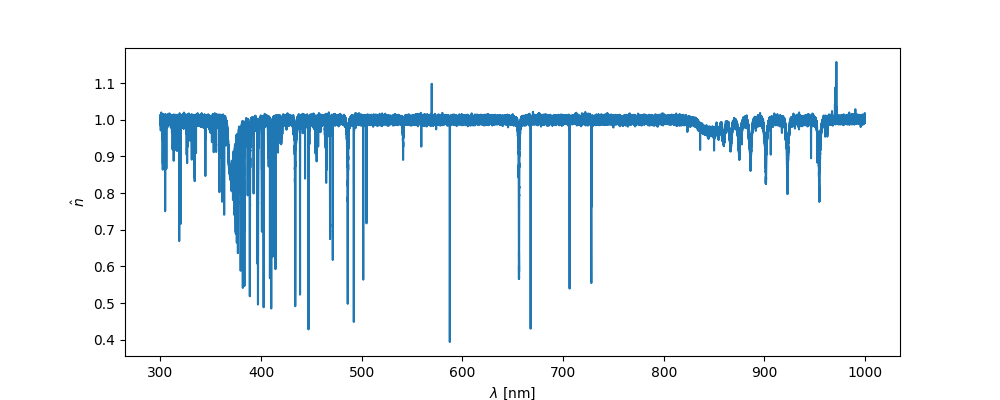

In [16]:
spectrum_sim.plot();

# Apply radial velocity shift

You can hoose if you want to create a new spectrum with an applied spectrum or overwrite the current spectrum.

In the following example, a new spectrum object is created with the same characteristics as before, only that it has a shifted spectrum given by the radial velocity.

spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - INFO - Keeping units of x: nm
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


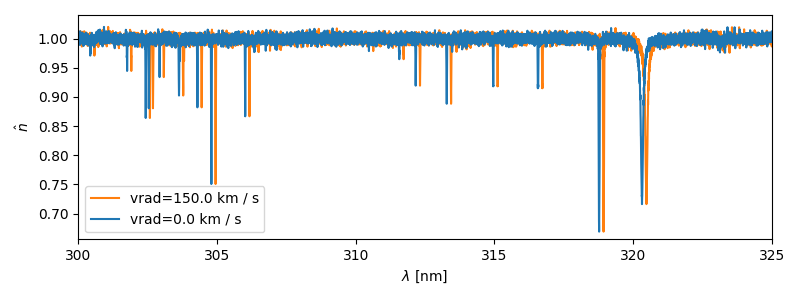

In [17]:
spectrum_shifted=spectrum_sim.apply_shift_vrad(150.,new_spectrum=True)
ax = spectrum_shifted.plot(x_unit=u.nm,interval=[300,325],fig_height=3,fig_width=8,color='C01',label=f'vrad={spectrum_shifted.vrad}');
spectrum_sim.plot(ax=ax,x_unit=u.nm,interval=[300,325],color='C00',label=f'vrad={spectrum_sim.vrad}');
ax.legend()
plt.tight_layout()

# Convert to velocity space

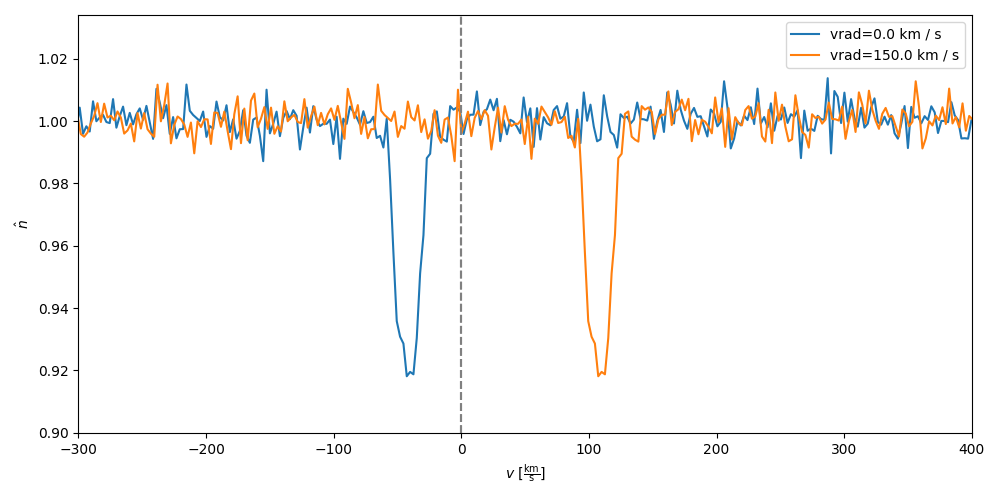

In [18]:
fig, ax = plt.subplots(figsize=(10,5))

#without radial shift
spectrum_sim.plot_velocity(x_rest=315*u.nm,interval=[-300,400],ax=ax,label=f'vrad={spectrum_sim.vrad}');

#with radial shift -> does not change whole spectrum, only for plotting
vrad = 150 * u.km / u.s
spectrum_sim.plot_velocity(x_rest=315*u.nm,vrad=vrad,ax=ax,color='C01',label=f'vrad={vrad}');

ax.legend()
plt.tight_layout()

When specifying an interval for the velocity plot, you can also use units for the interval. You can use velocity but also wavelength, energy or frequency units:



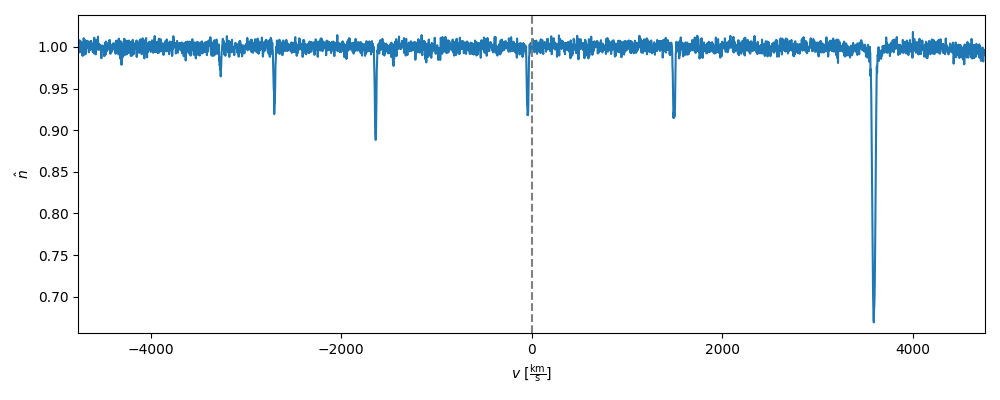

In [19]:
interval_units = [310,320] * u.nm
spectrum_sim.plot_velocity(x_rest=315*u.nm,interval=interval_units,label=f'vrad={spectrum_sim.vrad}');
plt.tight_layout()

# Line Identification

You can easily implement line identification by setting up a Line Identifier. 

You can choose the text and line style for all lines by setting a line_kwargs dictionary that is given to all ax.vlines and ax.hlines and text_kwargs that are given to specify all ax.text()

In [20]:
line_kwargs = {'color':'red'}
text_kwargs =  {'color':'green'}

## From simple dictionary
You can create a LineIdentifier from a simple dictionary and plot it:

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.02 to ymax_new=1.26


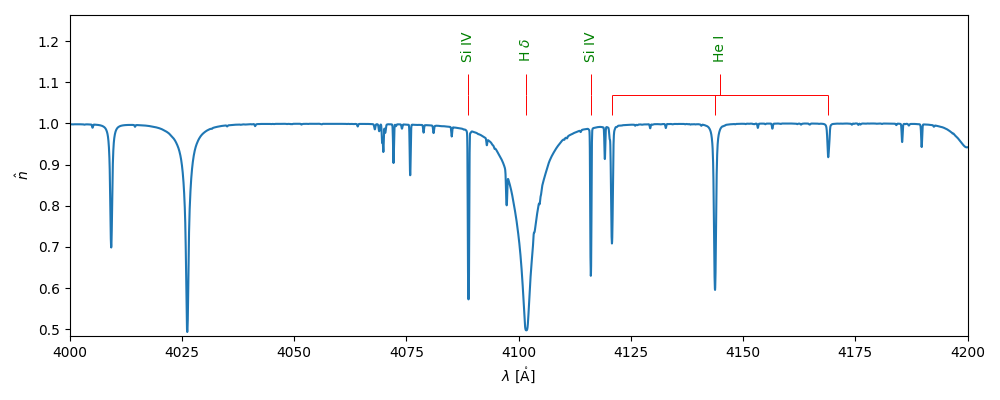

In [21]:
# Plot the spectrum
ax = spectrum_norm.plot(x_unit=u.AA,interval=[4000,4200]);

line_info = {'He I':[[4120.8,4143.8,4168.97],[4471]],'Si IV':[[4088.8],[4116.1]],'H $\delta$':[4101.7]}

li = LineIdentifier.from_dict(line_info)
ax = li.plot(ax=ax,line_kwargs=line_kwargs,text_kwargs=text_kwargs,root=0.05,stem=0.05)

plt.tight_layout()

## Create line idents WRPLot like ident file
Or you can import the lineidentifier from a PoWR ident file. In that case, a specified name string will be translated into latex format and a dictionary containing the text style formatting. 
First, you have to read the ident file and then you can plot the lines. 
You can find a summary of all the WRPlot Text attributes on p. 27 in the WrPlot manual

If the text and lines reach out of the given figure, the ylim is adapted accordingly so that the whole textstays within the figure.

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


O$\,$II: {'wavelengths': [[4007.462]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$IV: {'wavelengths': [[4057.76]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
Si$\,$IV: {'wavelengths': [[4088.8], [4116.1]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$III: {'wavelengths': [[4097.35]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
H$\delta$: {'wavelengths': [[4101.7]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$I: {'wavelengths': [[4120.8, 4143.8, 4168.97]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$II: {'wavelengths': [[4199.9, 4201.0]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}



spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.02 to ymax_new=1.26


<Axes: xlabel='$\\lambda$ [$\\mathrm{\\mathring{A}}$]', ylabel='$\\hat{n}$'>

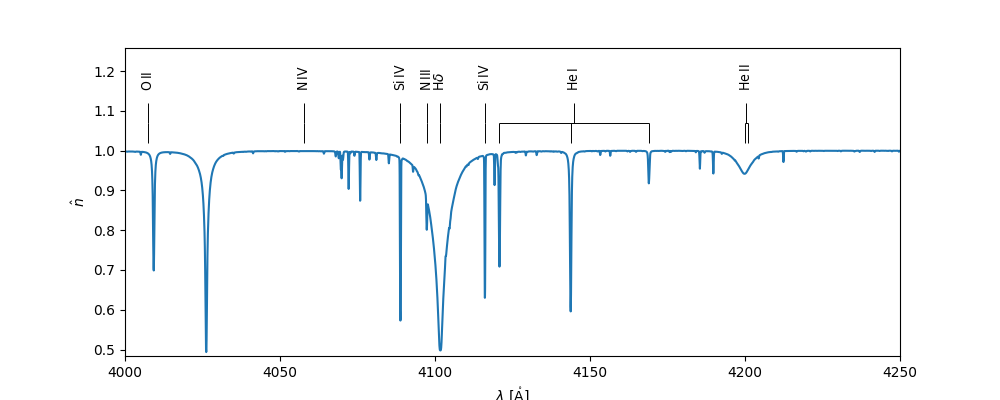

In [22]:
# Plot the spectrum
ax = spectrum_norm.plot(x_unit=u.AA,interval=[4000,4250]);

li = LineIdentifier.from_powr_identfile(filename='../tests/test_data/ident_O.dat')
print(li)
li.plot(ax=ax)

A few suggestions on how to work with the LineIdentifier

In [23]:
# Show the Line Identifier
print('Summary of LineIdentifier')
print(li)

# show the spectral lines of a given ion. For now, you have to use the full latex name
print('\nThe SpectralLine object for a given ion')
print(li.spectral_lines['Si$\\,$IV'])

# You can also just show the lines for one specific ion
# It is a list of lists
#List of single element: single line
#List of multiple elements: multiplet
print('\nHere are the lines corresponding to Si IV')
print(li.get_ion_lines('Si$\,$IV'))

Summary of LineIdentifier
O$\,$II: {'wavelengths': [[4007.462]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$IV: {'wavelengths': [[4057.76]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
Si$\,$IV: {'wavelengths': [[4088.8], [4116.1]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$III: {'wavelengths': [[4097.35]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
H$\delta$: {'wavelengths': [[4101.7]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$I: {'wavelengths': [[4120.8, 4143.8, 4168.97]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$II: {'wavelengths': [[4199.9, 4201.0]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}


The SpectralLine object for a given ion
SpectralLine(Si$\,$IV:
	[[4088.8], [4116.1]],
	{'fontstretch': 'ultra-condensed'})

Here are the lines corresponding to Si IV
[[4088.8], [4116.1]]


## Adding Lines
You can add a line to the LineIdentifier in the following way:

In [24]:
heI_line = SpectralLine('He$\,$I',402.62,plotting_style_dict={'color':'red'},x_unit=u.nm) 
li.add_spectral_line(heI_line)
print(li)

O$\,$II: {'wavelengths': [[4007.462]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$IV: {'wavelengths': [[4057.76]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
Si$\,$IV: {'wavelengths': [[4088.8], [4116.1]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$III: {'wavelengths': [[4097.35]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
H$\delta$: {'wavelengths': [[4101.7]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$I: {'wavelengths': [[4120.8, 4143.8, 4168.97], [4026.1999999999994]], 'plotting_style': {'fontstretch': 'ultra-condensed', 'color': 'red'}}
He$\,$II: {'wavelengths': [[4199.9, 4201.0]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}



Notice that the text style of all ion names was adapted. If the x_unit of the line is given in a different unit than the rest of the lines, it is converted to the rest of the LineIdentifier

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.02 to ymax_new=1.26


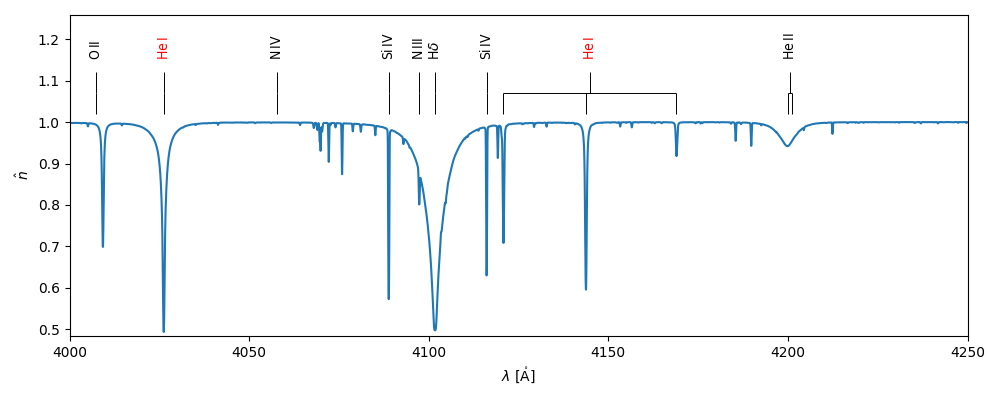

In [25]:
# Plot the spectrum
ax = spectrum_norm.plot(x_unit=u.AA,interval=[4000,4250]);

ax = li.plot(ax=ax)
plt.tight_layout()

## Update plotting style
You can also adapt the text plotting style of a given element:

In [26]:
li.update_plotting_style('N$\,$IV',new_plotting_style={'weight':'bold'})

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.02 to ymax_new=1.27


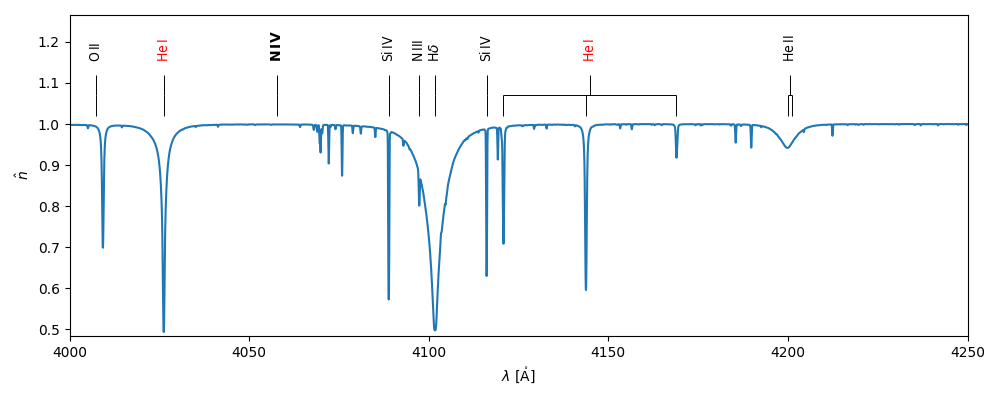

In [27]:
# Plot the spectrum
ax = spectrum_norm.plot(x_unit=u.AA,interval=[4000,4250]);

ax = li.plot(ax=ax)
plt.tight_layout()

## Write/ Read to yaml
You can write and read the line idents also from a more readable yaml file:

In [28]:
li.to_dict()

{'O$\\,$II': {'wavelengths': [[4007.462]],
  'plotting_style': {'fontstretch': 'ultra-condensed'}},
 'N$\\,$IV': {'wavelengths': [[4057.76]],
  'plotting_style': {'weight': 'bold'}},
 'Si$\\,$IV': {'wavelengths': [[4088.8], [4116.1]],
  'plotting_style': {'fontstretch': 'ultra-condensed'}},
 'N$\\,$III': {'wavelengths': [[4097.35]],
  'plotting_style': {'fontstretch': 'ultra-condensed'}},
 'H$\\delta$': {'wavelengths': [[4101.7]],
  'plotting_style': {'fontstretch': 'ultra-condensed'}},
 'He$\\,$I': {'wavelengths': [[4120.8, 4143.8, 4168.97], [4026.1999999999994]],
  'plotting_style': {'fontstretch': 'ultra-condensed', 'color': 'red'}},
 'He$\\,$II': {'wavelengths': [[4199.9, 4201.0]],
  'plotting_style': {'fontstretch': 'ultra-condensed'}}}

In [29]:
# You can write the current line identifier to a yaml file
li.to_yaml('test.yaml')

In [30]:
# And read it back in:
li = LineIdentifier.from_yaml('test.yaml')

In [31]:
print(li)

H$\delta$: {'wavelengths': [[4101.7]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$I: {'wavelengths': [[4120.8, 4143.8, 4168.97], [4026.1999999999994]], 'plotting_style': {'color': 'red', 'fontstretch': 'ultra-condensed'}}
He$\,$II: {'wavelengths': [[4199.9, 4201.0]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$III: {'wavelengths': [[4097.35]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$IV: {'wavelengths': [[4057.76]], 'plotting_style': {'weight': 'bold'}}
O$\,$II: {'wavelengths': [[4007.462]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
Si$\,$IV: {'wavelengths': [[4088.8], [4116.1]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}



## Units

In [32]:
li.convert_units(u.nm)

In [33]:
print(li)

H$\delta$: {'wavelengths': [[410.17]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
He$\,$I: {'wavelengths': [[412.08000000000004, 414.38000000000005, 416.89700000000005], [402.61999999999995]], 'plotting_style': {'color': 'red', 'fontstretch': 'ultra-condensed'}}
He$\,$II: {'wavelengths': [[419.99, 420.1]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$III: {'wavelengths': [[409.73500000000007]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
N$\,$IV: {'wavelengths': [[405.77600000000007]], 'plotting_style': {'weight': 'bold'}}
O$\,$II: {'wavelengths': [[400.74620000000004]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}
Si$\,$IV: {'wavelengths': [[408.88000000000005], [411.61000000000007]], 'plotting_style': {'fontstretch': 'ultra-condensed'}}



In [34]:
li.x_unit

Unit("nm")

## With radial velocity shift

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.04 to ymax_new=1.27


<Axes: xlabel='$\\lambda$ [$\\mathrm{nm}$]', ylabel='$\\hat{n}$'>

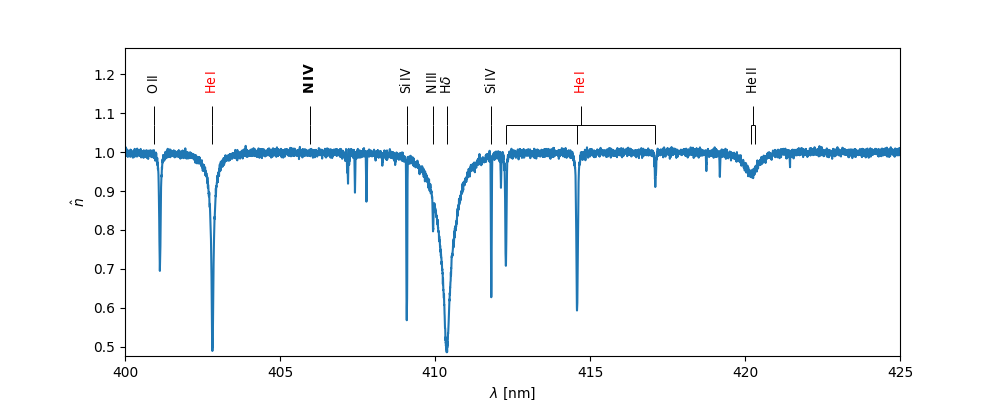

In [35]:
ax = spectrum_shifted.plot(interval=[400,425])

li.apply_shift_vrad(spectrum_shifted.vrad)
li.plot(ax=ax)

# Combine two spectra
Two spectra can only be combined if they have the same x and y units. In overlapping regions, the spectra are combined using SNR weighted means. If no error exists for the spectra, the weights are 1, and the normal mean is used.

In [36]:
# Simulate two spectra with different noise to show how combination works
mask1 = (spectrum_norm.x.value > 4300) & (spectrum_norm.x.value < 4400)
x1,y1 = spectrum_norm.x[mask1], spectrum_norm.y[mask1]
yerr1 = np.random.normal(scale=0.05,size=len(y1))*y1.value
sp1 = Spectrum(x=x1,y=y1+yerr1,yerr=[0.05]*len(y1)*y1.unit)

mask2 = (spectrum_norm.x.value > 4350) & (spectrum_norm.x.value < 4500)
x2,y2 = spectrum_norm.x[mask2], spectrum_norm.y[mask2]
yerr2 = np.random.normal(scale=0.1,size=len(y2))*y2.value
sp2 = Spectrum(x=x2,y=y2+yerr2,yerr=[0.1]*len(y2)*y2.unit)

spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 


In [44]:
# Combine both spectra
sp_comb = sp1 + sp2
# The combination operation of spectra is commutative:
sp_comb2 = sp2 + sp1

spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


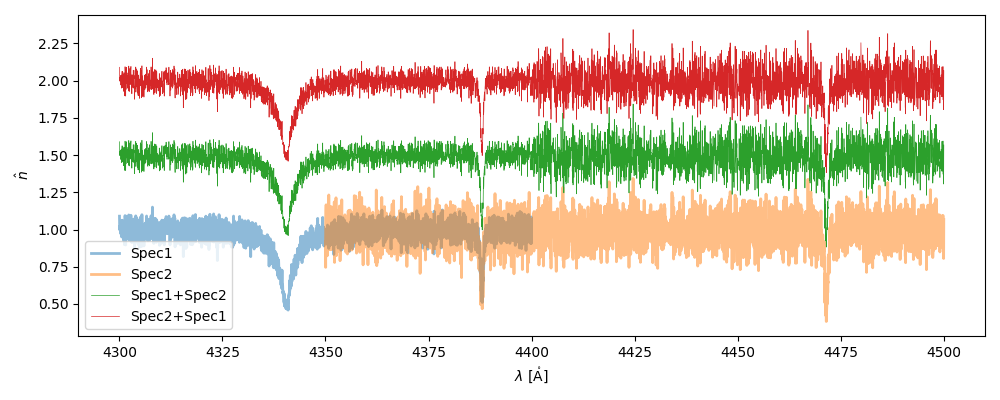

In [46]:
# Show combination of spectra
ax=sp1.plot(label='Spec1',alpha=0.5,lw=2)
sp2.plot(ax=ax,label='Spec2',alpha=0.5,lw=2)
sp_comb.plot(ax=ax,label='Spec1+Spec2',alpha=1,lw=0.5,yshift=0.5)
sp_comb2.plot(ax=ax,label='Spec2+Spec1',alpha=1,lw=0.5,yshift=1.0)
ax.legend()
plt.tight_layout()